# Segmentation des Profils de Consommation de Gaz: Intérêt et Méthodologie

# Préparation des données

In [1]:
%load_ext autoreload
%autoreload 2
#Basic Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

In [2]:
from datetime import datetime, timedelta
from gas_intelligence.retrieve_data import get_consumption_data

date_start = "2020-01-01"
date_end = "2025-12-01"

date_start, date_end

# une fois que le dataset est téléchargé on va directement le récupéré depuis le dossier data
# df = get_consumption_data(date_start=date_start,
#                           date_end=date_end,
#                           period_type="day"
#                          )

df = pd.read_csv(f"../data/raw/consumption_{date_start}_to_{date_end}_day.csv")

/tmp/ipykernel_25507/1127236457.py:15: DtypeWarning: Columns (0: flowStatus, 1: originalPeriodFrom, 2: bookingPlatformKey, 3: bookingPlatformURL, 4: pointType) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"../data/raw/consumption_{date_start}_to_{date_end}_day.csv")


## Tableau des colonnes ENTSO-G (35 colonnes)

| # | Colonne | Type | Description | Utile clustering? | Exemple |
|---|---------|------|-------------|------------------|---------|
| 1 | `id` | string | Identifiant unique du flux | ❌ | "1Physical Flowday2026-05-17..." |
| 2 | `dataSet` | int | Version dataset | ❌ | `1` |
| 3 | `indicator` | string | Type d'indicateur | ❌ | `"Physical Flow"` |
| 4 | `periodType` | string | Granularité (day/month/year) | ⚠️ | `"day"` |
| 5 | `periodFrom` | datetime | Début de période | ✅ CRITIQUE | `"2026-05-17 06:00"` |
| 6 | `periodTo` | datetime | Fin de période | ⚠️ | `"2026-05-18 06:00"` |
| 7 | `operatorKey` | string | Code TSO (pays) | ⚠️ | `"FI-TSO-0003"` |
| 8 | `tsoEicCode` | string | Code EIC opérateur | ❌ | `"21X000000001393X"` |
| 9 | `operatorLabel` | string | Nom opérateur | ⚠️ | `"Gasgrid Finland"` |
| 10 | `pointKey` | string | Code point | ⚠️ | `"LNG-00072"` |
| 11 | `pointLabel` | string | Nom point | ⚠️ | `"Inkoo LNG (FI)"` |
| 12 | `tsoItemIdentifier` | string | ID interne TSO | ❌ | `"21Z000000000531O"` |
| 13 | `directionKey` | string | entry ou exit | ✅ CRITIQUE | `"exit"` |
| 14 | `unit` | string | Unité mesure | ✅ CRITIQUE | `"kWh/d"` |
| 15 | `itemRemarks` | string | Remarques item | ❌ | (vide généralement) |
| 16 | `generalRemarks` | string | Remarques générales | ❌ | (vide généralement) |
| 17 | `value` | float | **Valeur consommation** | ✅ CRITIQUE | `86520924.44` |
| 18 | `lastUpdateDateTime` | datetime | Dernière maj | ⚠️ | `"2026-05-24 08:05"` |
| 19 | `isUnlimited` | bool/string | Capacité illimitée? | ❌ | (vide) |
| 20 | `flowStatus` | string | Statut (Provisional/Confirmed) | ⚠️ | `"Provisional"` |
| 21 | `interruptionType` | string | Type interruption | ❌ | (vide généralement) |
| 22 | `restorationInformation` | string | Info restauration | ❌ | (vide généralement) |
| 23 | `capacityType` | string | Type capacité | ❌ | (vide généralement) |
| 24 | `capacityBookingStatus` | string | Statut réservation | ❌ | (vide généralement) |
| 25 | `isCamRelevant` | int/bool | CAM applicable? | ❌ | `1` ou (vide) |
| 26 | `isNA` | bool/string | Donnée manquante? | ⚠️ | (vide = disponible) |
| 27 | `originalPeriodFrom` | string | Période orig. | ❌ | (vide généralement) |
| 28 | `isCmpRelevant` | int/bool | CMP applicable? | ❌ | `1` ou (vide) |
| 29 | `bookingPlatformKey` | string | Plateforme résa | ❌ | `"PRISMA"` |
| 30 | `bookingPlatformLabel` | string | Nom plateforme | ❌ | `"Capacity booking..."` |
| 31 | `bookingPlatformURL` | string | URL plateforme | ❌ | `"https://platform.prisma..."` |
| 32 | `interruptionCalculationRemark` | string | Remarque calc | ❌ | (vide généralement) |
| 33 | `pointType` | string | Type point (texte) | ✅ CRUCIAL | `"Aggregated Point - Final Consumers"` |
| 34 | `idPointType` | int | Type point (ID) | ✅ CRUCIAL | `18` (Final Consumers) |
| 35 | `isArchived` | bool/string | Donnée archivée? | ❌ | (vide généralement) |

---

### **Les colonnes CRITIQUES à retenir pour notre clustering:**

```
✅ periodFrom         → Axe temporal (saisonnalité)
✅ directionKey       → Filtrer sur "exit" (consommation)
✅ value              → La donnée de consommation (kWh/d)
✅ unit               → kWh/d (on pourra convertir si besoin en GWh/d)
✅ pointType          → Filtrer sur "Aggregated Point - Final Consumers"
✅ idPointType        → Filtrer sur valeur 18 pour les Final Consumers.
```


In [3]:
df_exit = df[
    (df['directionKey'] == 'exit') &      # Sortie du réseau
    (df['value'].notna()) &               # Valeur de consommation disponible
    (df['flowStatus'] == 'Confirmed') &   # Flux confirmé seulement
    (df['idPointType'] == 18)             # Garder que les consommateurs finaux
    ]

In [4]:
df_exit['idPointType'].value_counts()

idPointType
18.0    60565
Name: count, dtype: int64

Passons au nettoyage et à la préparation des données :

In [5]:
# 1. Convertir dates
df_exit['date'] = pd.to_datetime(df_exit['periodFrom'])
df_exit['année'] = df_exit['date'].dt.year
df_exit['mois'] = df_exit['date'].dt.month
df_exit['jour_semaine'] = df_exit['date'].dt.dayofweek  # 0=lundi, 6=dimanche
df_exit['semaine_année'] = df_exit['date'].dt.isocalendar().week
df_exit['saison'] = df_exit['mois'].apply(lambda m: 'été' if 4 <= m <= 9 else 'hiver')
df_exit['is_weekend'] = np.where(df_exit['jour_semaine'].isin([5, 6]), True, False)

# 2. Convertir la valeur en GWh (de kWh/d à GWh/d)
df_exit['value_gwh'] = df_exit['value'].astype(float) / 1_000_000

# 3. Supprimer les valeurs manquantes
df_exit = df_exit[df_exit['value_gwh'].notna()]

## Création de nos features

| Feature | Définition | Interprétation |
|---------|-----------|---|
| **conso_mean** | μ (conso quotidienne) | Taille du point |
| **conso_std** | σ (écart type) | Utile pour le calcul de la volatilité |
| **conso_min** | min(conso) | Donne la plus petite conso pour un jour à ce point |
| **conso_max** | max(conso) | Donne la plus grande conso pour un jour à ce point |
| **volatilite** | σ (conso) / μ(conso) | Variabilité |
| **ratio_hiver_ete** | conso_hiver / conso_été | Saisonnalité |
| **ratio_we_wd** | conso_weekend / conso_weekday | Effet week-end |

In [6]:
# Agréger par point
profils = df_exit.groupby('pointKey').agg({
    'pointLabel': 'first',
    'operatorLabel': 'first',
    'operatorKey': 'first',
    'value_gwh': ['mean', 'std', 'min', 'max'],
}).reset_index()

# Aplatir colonnes
profils.columns = ['pointKey', 'pointLabel', 'operatorLabel', 'operatorKey',
                   'conso_mean', 'conso_std', 'conso_min', 'conso_max']

# ===== FEATURE 1: Volatilité =====
# Éviter division par zéro
profils['volatilite'] = profils.apply(
    lambda row: row['conso_std'] / row['conso_mean']
    if row['conso_mean'] > 0 else np.nan,
    axis=1
)

# ===== FEATURE 2: Saisonnalité hiver vs été =====
saisonnalite = df_exit.groupby(['pointKey', 'saison'])['value_gwh'].mean().unstack(fill_value=np.nan)

# Calculer le ratio AVEC gestion des cas limites
saisonnalite['ratio_hiver_ete'] = saisonnalite.apply(
    lambda row: row['hiver'] / row['été']
    if (row['hiver'] > 0) and (row['été'] > 0) else np.nan,
    axis=1
)

saisonnalite = saisonnalite.reset_index()

# Fusionner
profils = profils.merge(
    saisonnalite[['pointKey', 'ratio_hiver_ete']],
    on='pointKey',
    how='left'
)

# ===== FEATURE 3: Variation weekend vs weekday =====
variation_weekend = df_exit.groupby(['pointKey', 'is_weekend'])['value_gwh'].mean().unstack(fill_value=np.nan)

# Calculer le ratio AVEC gestion des cas limites
variation_weekend['ratio_we_wd'] = variation_weekend.apply(
    lambda row: row[True] / row[False]  # True = weekend, False = weekday
    if (row[True] > 0) and (row[False] > 0) else np.nan,
    axis=1
)

variation_weekend = variation_weekend.reset_index()

# Fusionner
profils = profils.merge(
    variation_weekend[['pointKey', 'ratio_we_wd']],
    on='pointKey',
    how='left'
)

In [7]:
profils.info()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pointKey         38 non-null     str    
 1   pointLabel       38 non-null     str    
 2   operatorLabel    38 non-null     str    
 3   operatorKey      38 non-null     str    
 4   conso_mean       38 non-null     float64
 5   conso_std        37 non-null     float64
 6   conso_min        38 non-null     float64
 7   conso_max        38 non-null     float64
 8   volatilite       37 non-null     float64
 9   ratio_hiver_ete  34 non-null     float64
 10  ratio_we_wd      37 non-null     float64
dtypes: float64(7), str(4)
memory usage: 3.4 KB


Essayons de comprendre la présence de ces valeurs manquantes.

In [8]:

# Compter les NaN par feature
print('Répartion des NaN par feature')
nan_counts = profils[['conso_std', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd']].isna().sum()
for feature, count in nan_counts.items():
    pct = (count / len(profils)) * 100
    print(f"   {feature}: {count} NaN ({pct:.1f}%)")


# Analyser les caractéristiques des points NaN

mask_any_nan = profils[['conso_std', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd']].isna().any(axis=1)
problematic = profils[mask_any_nan]

print(f"\n Statistiques points avec NaN:")
print(f"   Conso mean: {problematic['conso_mean'].mean():.2f} GWh/j (vs {profils['conso_mean'].mean():.2f} all points)")
print(f"   Conso std:  {problematic['conso_std'].mean():.2f} (vs {profils['conso_std'].mean():.2f} all points)")
print(f"   Conso min:  {problematic['conso_min'].mean():.2f}")
print(f"   Conso max:  {problematic['conso_max'].mean():.2f}")


Répartion des NaN par feature
   conso_std: 1 NaN (2.6%)
   volatilite: 1 NaN (2.6%)
   ratio_hiver_ete: 4 NaN (10.5%)
   ratio_we_wd: 1 NaN (2.6%)

 Statistiques points avec NaN:
   Conso mean: 175.82 GWh/j (vs 117.98 all points)
   Conso std:  48.47 (vs 201.86 all points)
   Conso min:  85.83
   Conso max:  261.40


Pour le point dont le volatilité est manquante, est ce lié au fait que la moyenne à ces points est nulle ?

In [9]:
vol_nan = profils[profils['volatilite'].isna()]
vol_nan


,pointKey,pointLabel,operatorLabel,operatorKey,conso_mean,conso_std,conso_min,conso_max,volatilite,ratio_hiver_ete,ratio_we_wd
37,FNC-00216,Aggregated exit to Switzerland,Swissgas,CH-TSO-0001,19.78524,NaN,19.78524,19.78524,NaN,NaN,NaN


On remarque ici que la volatilité est nulle car le point n'a été livré qu'une fois en 5 ans, on le supprime il n'est pas pertinent.

In [10]:
profils = profils.dropna(subset=['volatilite'])

In [11]:
profils.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pointKey         37 non-null     str    
 1   pointLabel       37 non-null     str    
 2   operatorLabel    37 non-null     str    
 3   operatorKey      37 non-null     str    
 4   conso_mean       37 non-null     float64
 5   conso_std        37 non-null     float64
 6   conso_min        37 non-null     float64
 7   conso_max        37 non-null     float64
 8   volatilite       37 non-null     float64
 9   ratio_hiver_ete  34 non-null     float64
 10  ratio_we_wd      37 non-null     float64
dtypes: float64(7), str(4)
memory usage: 3.3 KB


Essayons de traiter les 3 NaN de la colonne ratio_hiver_ete

In [12]:
idx_na_ratio_he = profils[profils['ratio_hiver_ete'].isna()].index

for idx in idx_na_ratio_he :
    point_key = profils.loc[idx, 'pointKey']
    point_label = profils.loc[idx, 'pointLabel']

    print(point_key, point_label)

    point_data = df_exit[df_exit['pointKey'] == point_key]

    hiver_mean = point_data[point_data['saison'] == 'hiver']['value_gwh'].mean()
    ete_mean = point_data[point_data['saison'] == 'été']['value_gwh'].mean()

    print(hiver_mean, ete_mean)

FNC-00013 Industrial Consumers (NL)
588.2295583616542 nan
FNC-00014 Private Distribution Companies (PDC) (NL)
18.767062015789474 nan
FNC-00200 Aggregated Final Consumers (HU)
76.50283969491525 nan


On se rend compte que c'est valeurs manquantes liées à une absence totale de consomation en été, on va remplacer ces valeurs manquantes par le max de la colonne ratio_hiver_ete

In [13]:
max_ratio_he = profils['ratio_hiver_ete'].max()

for idx in idx_na_ratio_he :
    profils.loc[idx, 'ratio_hiver_ete'] = max_ratio_he

In [14]:
profils.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pointKey         37 non-null     str    
 1   pointLabel       37 non-null     str    
 2   operatorLabel    37 non-null     str    
 3   operatorKey      37 non-null     str    
 4   conso_mean       37 non-null     float64
 5   conso_std        37 non-null     float64
 6   conso_min        37 non-null     float64
 7   conso_max        37 non-null     float64
 8   volatilite       37 non-null     float64
 9   ratio_hiver_ete  37 non-null     float64
 10  ratio_we_wd      37 non-null     float64
dtypes: float64(7), str(4)
memory usage: 3.3 KB


On va sauvegarder notre dataset profils_clean dans un fichier CSV pour l'utiliser plus facilement à l'avenir.

In [15]:
profils.to_csv('../data/clean/final_consumers_profiles.csv')

### A partir de maintenant nous allons uniquement utilisé le CSV clean

In [16]:
profils_clean = pd.read_csv('../data/clean/final_consumers_profiles.csv')

# Exploration des distributions

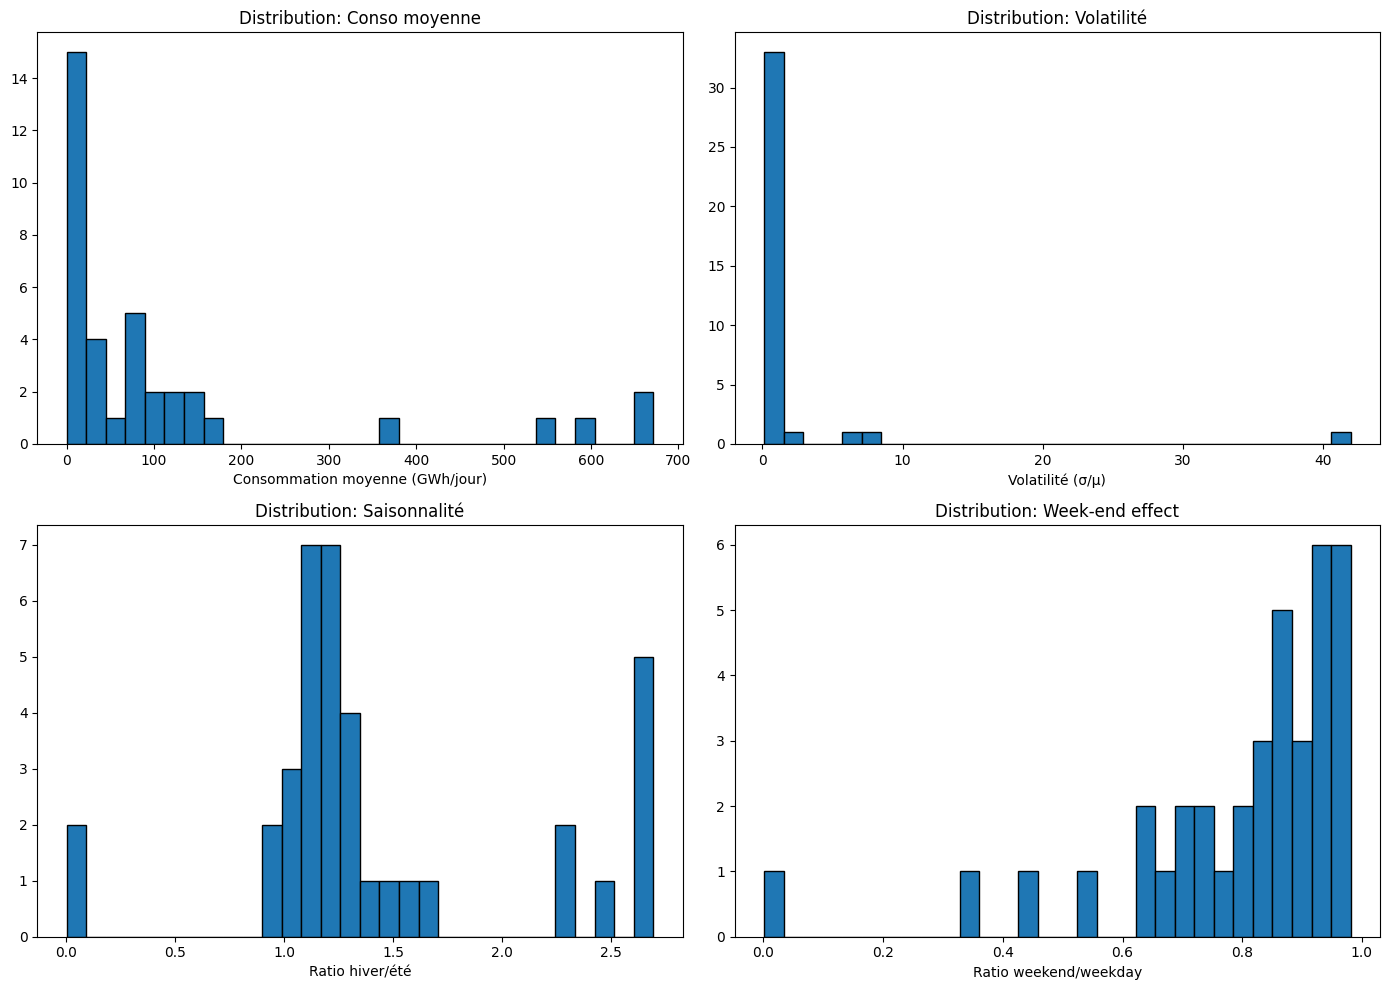

Statistiques descriptives:
       conso_mean  volatilite  ratio_hiver_ete  ratio_we_wd
count   37.000000   37.000000        37.000000    37.000000
mean   120.638969    1.934017         1.437990     0.795859
std    189.451202    6.945446         0.676205     0.202606
min      0.001726    0.121788         0.001739     0.001262
25%     10.729005    0.222329         1.107555     0.730254
50%     34.713267    0.309213         1.230377     0.872220
75%    124.004559    0.687226         1.570928     0.922612
max    671.125218   41.951894         2.694221     0.981230


In [17]:
# Visualiser les distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(profils_clean['conso_mean'], bins=30, edgecolor='black')
axes[0, 0].set_xlabel('Consommation moyenne (GWh/jour)')
axes[0, 0].set_title('Distribution: Conso moyenne')

axes[0, 1].hist(profils_clean['volatilite'], bins=30, edgecolor='black')
axes[0, 1].set_xlabel('Volatilité (σ/μ)')
axes[0, 1].set_title('Distribution: Volatilité')

axes[1, 0].hist(profils_clean['ratio_hiver_ete'], bins=30, edgecolor='black')
axes[1, 0].set_xlabel('Ratio hiver/été')
axes[1, 0].set_title('Distribution: Saisonnalité')

axes[1, 1].hist(profils_clean['ratio_we_wd'], bins=30, edgecolor='black')
axes[1, 1].set_xlabel('Ratio weekend/weekday')
axes[1, 1].set_title('Distribution: Week-end effect')

plt.tight_layout()
plt.show()

# Statistiques
print("Statistiques descriptives:")
print(profils_clean[['conso_mean', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd']].describe())

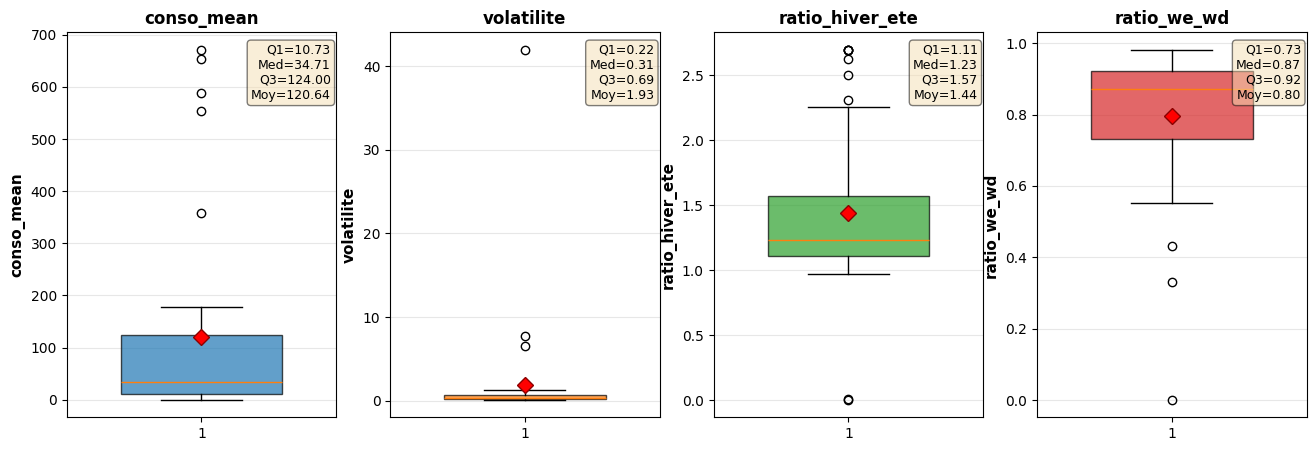

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

features = ['conso_mean', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, (ax, feature, color) in enumerate(zip(axes, features, colors)):
    # Boxplot
    bp = ax.boxplot(
        profils[feature].dropna(),
        vert=True,
        patch_artist=True,
        widths=0.6,
        showmeans=True,
        meanprops=dict(marker='D', markerfacecolor='red', markeredgecolor='darkred', markersize=8)
    )

    # Couleurs
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel(feature, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title(f'{feature}', fontsize=12, fontweight='bold')

    # Ajouter stats
    q1 = profils[feature].quantile(0.25)
    med = profils[feature].median()
    q3 = profils[feature].quantile(0.75)
    mean_val = profils[feature].mean()

    stats_text = f'Q1={q1:.2f}\nMed={med:.2f}\nQ3={q3:.2f}\nMoy={mean_val:.2f}'
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


#### Essayons de comprendre à quoi correspondent les outliers

In [19]:
outliers = profils[
    (profils['conso_mean'] > 600) |      # Gros industriels
    (profils['volatilite'] > 15) |       # Très volatiles
    (profils['ratio_hiver_ete'] < 0.1)   # Zéro saisonnalité
].copy()

outliers_pointKeys = outliers.pointKey

print(f"Outliers identifiés: {len(outliers)} points")
outliers

Outliers identifiés: 4 points


,pointKey,pointLabel,operatorLabel,operatorKey,conso_mean,conso_std,conso_min,conso_max,volatilite,ratio_hiver_ete,ratio_we_wd
5,FNC-00006,Thermal Plants (IT),Snam Rete Gas,IT-TSO-0001,671.125218,214.486948,180.166907,1296.833127,0.319593,1.136741,0.644815
6,FNC-00007,Gas mixing facilities (PL),GAZ-SYSTEM,PL-TSO-0002,0.001726,0.013452,0.000000,0.190892,7.793211,0.005875,0.738416
22,FNC-00043,Aggregated Distribution + Final Customers Exit...,Enagas,ES-TSO-0006,652.918542,159.707854,350.737669,1342.155142,0.244606,1.223743,0.814557
30,FNC-00206,Final Consumers DE GTG Nord H Gas,Gastransport Nord,DE-TSO-0006,140.925963,5912.111024,0.000017,248871.561625,41.951894,0.001739,0.001262


In [20]:
profils = profils[~profils['pointKey'].isin(outliers_pointKeys)]

# Normalisation et Clustering Statistique

On ne va conserver que 4 features pour le clustering statistique : conso_mean, volatilite, ratio_hiver_ete et ratio_we_wd.  
Ces 4 features ont des échelles différentes, pour éviter que notre modèle ne fasses dominer une feature plutôt qu'une autre on va appliquer un scaling robuste sur toute nos features.

In [21]:
from sklearn.preprocessing import StandardScaler

profils_clean = profils.copy()

# Sélectionner features pour clustering
features_clustering = ['conso_mean', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd']

# Normaliser (OBLIGATOIRE pour K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(profils_clean[features_clustering])

## Choix du nombre de cluster optimal

On commence par chercher le nombre optimal de cluster d'un point de vu statistique.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

K_range = range(2, 15) # on teste de 2 à 14 clusters

inertias = []
silhouette_scores = []
db_scores = []

for k in K_range:

    # Entraîner KMeans
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_scaled)

    # Métriques
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels_temp))
    db_scores.append(davies_bouldin_score(X_scaled, labels_temp))

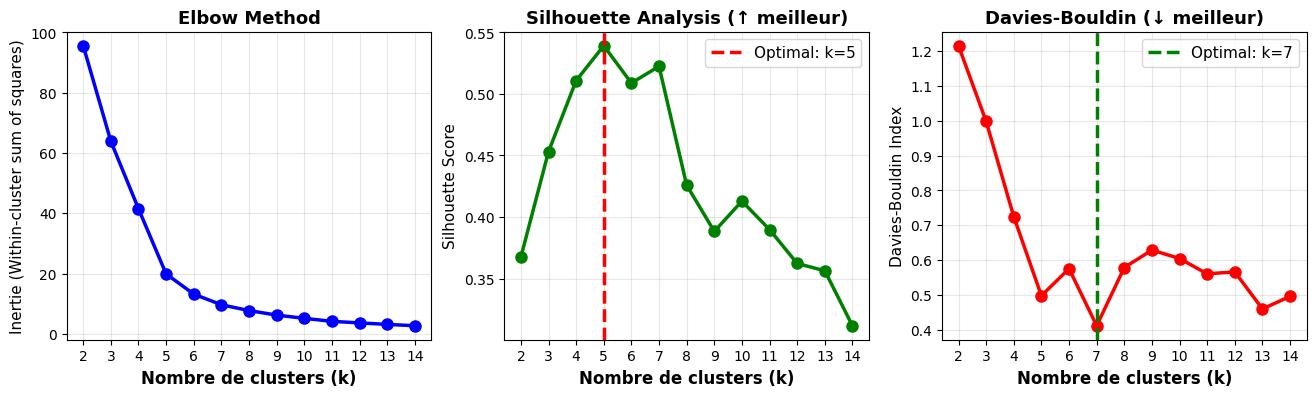

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ELBOW PLOT
axes[0].plot(K_range, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Nombre de clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertie (Within-cluster sum of squares)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_range)

# SILOUHETTE SCORE (plus élevé = mieux)
best_sil = K_range[np.argmax(silhouette_scores)]
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2.5, markersize=8)
axes[1].axvline(best_sil, color='red', linestyle='--', linewidth=2.5, label=f'Optimal: k={best_sil}')
axes[1].set_xlabel('Nombre de clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Analysis (↑ meilleur)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)
axes[1].set_xticks(K_range)

# DAVIES-BOULDIN (plus bas = mieux)
best_db = K_range[np.argmin(db_scores)]
axes[2].plot(K_range, db_scores, 'ro-', linewidth=2.5, markersize=8)
axes[2].axvline(best_db, color='green', linestyle='--', linewidth=2.5, label=f'Optimal: k={best_db}')
axes[2].set_xlabel('Nombre de clusters (k)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[2].set_title('Davies-Bouldin (↓ meilleur)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=11)
axes[2].set_xticks(K_range);

**CHOIX FINAL**

Au vu des résultats et de nos besoins nous allons partir sur k=5.

## KMeans

#### KMeans avec k=5

In [24]:
k_final = 5

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
profils_clean['cluster'] = kmeans_final.fit_predict(X_scaled)

In [25]:
print("📊 Distribution des clusters:")
distribution = profils_clean['cluster'].value_counts().sort_index()
for cluster_id, count in distribution.items():
    pct = (count / len(profils_clean)) * 100
    print(f"   Cluster {cluster_id}: {count:3d} points ({pct:5.1f}%)")

📊 Distribution des clusters:
   Cluster 0:  17 points ( 51.5%)
   Cluster 1:   2 points (  6.1%)
   Cluster 2:   1 points (  3.0%)
   Cluster 3:   6 points ( 18.2%)
   Cluster 4:   7 points ( 21.2%)


La taille des cluster 1 et 2 montre que le choix K=5 n'est pas viable.
K=5 statistiquement optimal ≠ K=5 pratiquement viable.

Même en passant à k=4 on a un cluster qui ne contient que 2 points, ainsi on décide de passer à k=3.b

#### KMeans avec K=3

In [26]:
k_final = 3

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
profils_kmeans = profils_clean.copy()
profils_kmeans['cluster'] = kmeans_final.fit_predict(X_scaled)

In [27]:
print("📊 Distribution des clusters:")
distribution = profils_kmeans['cluster'].value_counts().sort_index()
for cluster_id, count in distribution.items():
    pct = (count / len(profils_kmeans)) * 100
    print(f"   Cluster {cluster_id}: {count:3d} points ({pct:5.1f}%)")


📊 Distribution des clusters:
   Cluster 0:   8 points ( 24.2%)
   Cluster 1:   4 points ( 12.1%)
   Cluster 2:  21 points ( 63.6%)


## DBSCAN

In [28]:
from sklearn.cluster import DBSCAN

eps = 1.2 # Valeur choisie après plusieurs tests, fournit les meilleurs résultats
min_samples = 3

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
profils_dbscan = profils_clean.copy()
profils_dbscan['cluster'] = dbscan.fit_predict(X_scaled)


In [29]:
print("📊 Distribution des clusters (DBSCAN):")
distribution = profils_dbscan['cluster'].value_counts().sort_index()
for cluster_id, count in distribution.items():
    if cluster_id == -1:
        label = "Bruit (non-classé)"
    else:
        label = f"Cluster {cluster_id}"
    pct = (count / len(profils_dbscan)) * 100
    print(f"   {label}: {count:3d} points ({pct:5.1f}%)")

📊 Distribution des clusters (DBSCAN):
   Bruit (non-classé):   4 points ( 12.1%)
   Cluster 0:  20 points ( 60.6%)
   Cluster 1:   6 points ( 18.2%)
   Cluster 2:   3 points (  9.1%)


In [30]:
# COMPARER AVEC KMEANS K=3

comparison = pd.DataFrame({
    'DBSCAN': [20, 6, 3, 4],
    'KMeans': [21, 8, 4, 0],
    'Profil': ['Résidentiel', 'Mixte', 'Industriel', 'Bruit/Non-classé']
})

print("\n" + comparison.to_string(index=False))

print("\nDifférences:")
print("   • DBSCAN classe 29/33 points (12.1% non-classés)")
print("   • KMeans classe 33/33 points (0% non-classés)")
print("   • DBSCAN identifie 4 points comme 'limites' (bruit)")

# IDENTIFIER LES POINTS DE BRUIT DBSCAN

bruit_points = profils_dbscan[profils_dbscan['cluster'] == -1]

print(f"\n{len(bruit_points)} points de bruit:\n")
for idx, (_, row) in enumerate(bruit_points.iterrows(), 1):

    # Quelle serait la classification KMeans?
    kmeans_label = profils_clean.loc[_, 'cluster']
    print(f'Label selon KMEans {kmeans_label}')

# CROSSTAB: DBSCAN vs KMEANS

# Ajouter KMeans si disponible
if 'cluster' in profils_clean.columns:
    profils_comparison = profils_clean.copy()
    profils_comparison['dbscan'] = profils_dbscan['cluster']

    crosstab = pd.crosstab(
        profils_comparison['cluster'].map({0: 'Mixte', 1: 'Industriel', 2: 'Résidentiel'}),
        profils_comparison['dbscan'].map({0: 'DB_Cluster0', 1: 'DB_Cluster1', 2: 'DB_Cluster2', -1: 'Bruit'}),
        margins=True
    )

    print("\n" + crosstab.to_string())



 DBSCAN  KMeans           Profil
     20      21      Résidentiel
      6       8            Mixte
      3       4       Industriel
      4       0 Bruit/Non-classé

Différences:
   • DBSCAN classe 29/33 points (12.1% non-classés)
   • KMeans classe 33/33 points (0% non-classés)
   • DBSCAN identifie 4 points comme 'limites' (bruit)

4 points de bruit:

Label selon KMEans 0
Label selon KMEans 1
Label selon KMEans 2
Label selon KMEans 1

dbscan       Bruit  DB_Cluster0  All
cluster                             
Industriel       2            0    2
Mixte            1           16   17
Résidentiel      1            0    1
All              4           16   20


## Clustering Hiérarchique (Dendogram)

In [31]:
from scipy.cluster.hierarchy import dendrogram, linkage

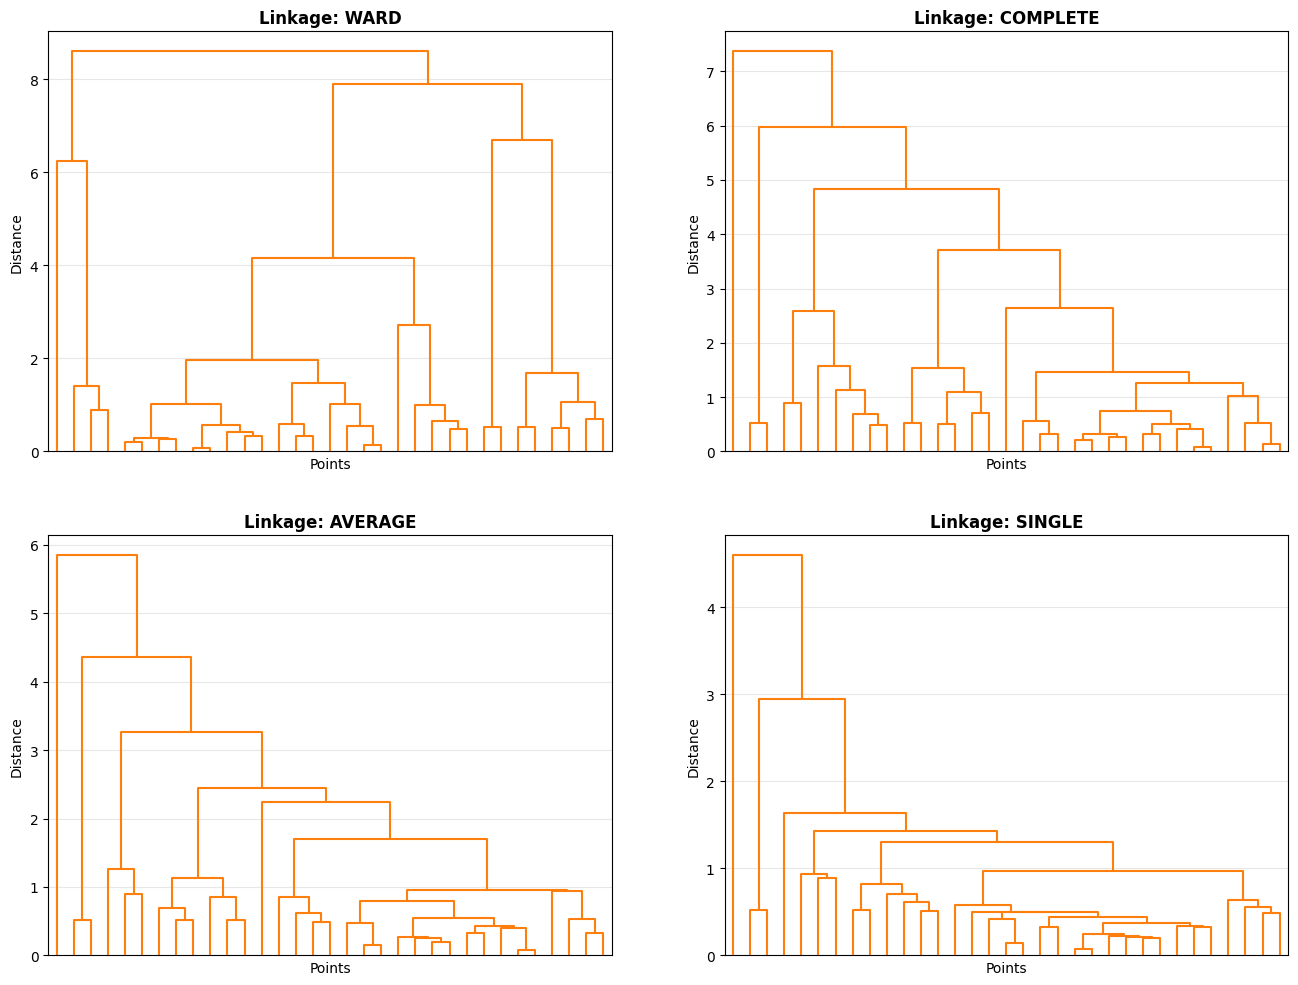

In [32]:
linkage_methods = ['ward', 'complete', 'average', 'single']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, method in zip(axes.flat, linkage_methods):
    # Calculer la matrice de linkage
    Z = linkage(X_scaled, method=method)

    # Dendrogramme
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=10)
    ax.set_title(f'Linkage: {method.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Points', fontsize=10)
    ax.set_ylabel('Distance', fontsize=10)
    ax.grid(True, alpha=0.3)

La meilleure méthode de linkage est clairement la méthode Ward.

Comparons ce clustering hiéarchique aux résultats de notre KMeans

Text(0, 0.5, 'Distance Euclidienne')

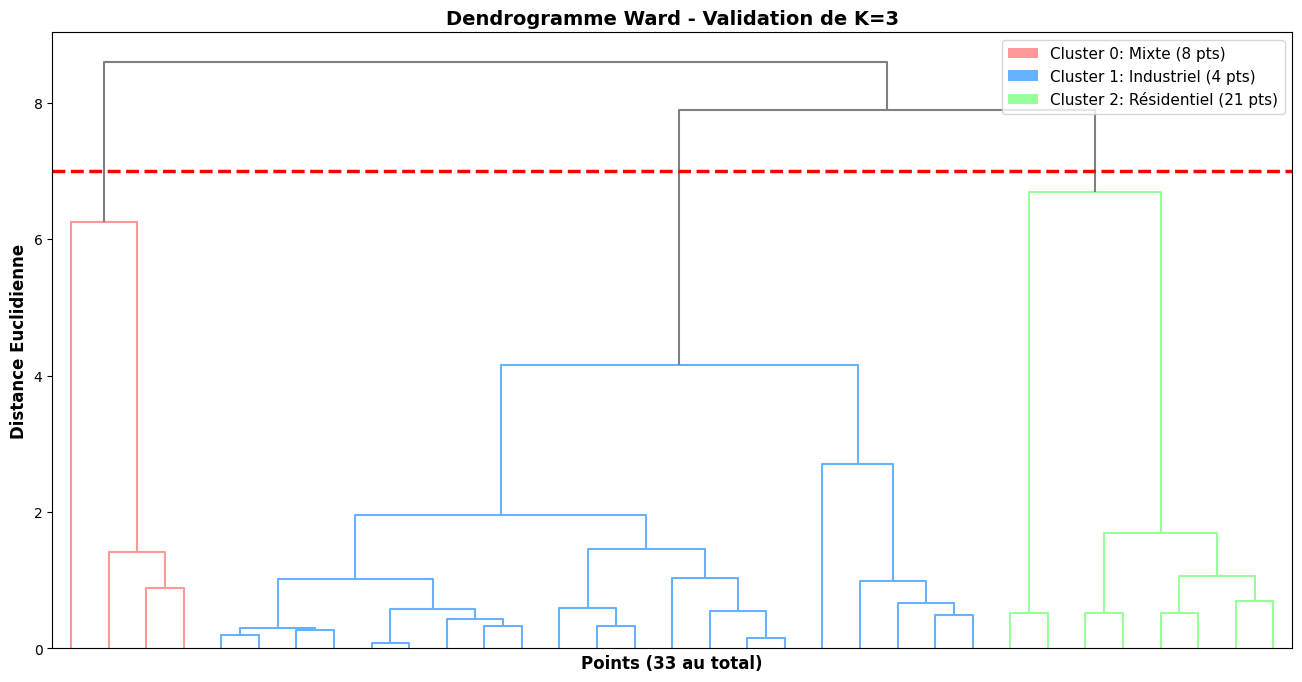

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage, set_link_color_palette

Z_ward = linkage(X_scaled, method='ward')

# Définir la palette de couleurs
set_link_color_palette(['#FF9999', '#66B2FF', '#99FF99'])

fig, ax = plt.subplots(figsize=(16, 8))

# Dendrogramme avec couleurs basées sur le seuil
dendrogram(
    Z_ward,
    ax=ax,
    no_labels=True,
    color_threshold=7,  # ← Seuil où les couleurs changent
    above_threshold_color='#808080'  # Gris pour les branches au-dessus du seuil
)

# Ajouter une ligne de coupure pour K=3
ax.axhline(y=7, color='red', linestyle='--', linewidth=2.5,
           label='Coupure K=3 (distance=15)');

# Ajouter légende
legend_elements = [
    Patch(facecolor='#FF9999', label='Cluster 0: Mixte (8 pts)'),
    Patch(facecolor='#66B2FF', label='Cluster 1: Industriel (4 pts)'),
    Patch(facecolor='#99FF99', label='Cluster 2: Résidentiel (21 pts)'),
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper right')

ax.set_title('Dendrogramme Ward - Validation de K=3', fontsize=14, fontweight='bold')
ax.set_xlabel('Points (33 au total)', fontsize=12, fontweight='bold')
ax.set_ylabel('Distance Euclidienne', fontsize=12, fontweight='bold')


# Analyse métier des résultats de la clusterisation

On va exploiter les clusters obtenus avec **KMeans (K=3)** sur les 33 points retenus (après retrait des 4 outliers).

> ⚠️ **Sémantique métier corrigée** (cf. §4 du `rapport.md`) — l'examen des centroïdes montre que les vrais axes discriminants sont **la saisonnalité** et **l'effet week-end / taille**, pas la dichotomie résidentiel vs industriel suggérée plus haut. Les labels sont donc :
>
> - **Cluster 0 — Saisonnier "chauffage dominant"** (8 points)
> - **Cluster 1 — Atypiques L-Gas / Tertiaire en déclin** (4 points)
> - **Cluster 2 — Industriel / Mixte continu** (21 points, ~64 %)

Le code ci-dessous extrait les centroïdes, les statistiques par cluster, les profils représentatifs, et construit un indicateur de dérive (`drift_zscore`) que le desk peut utiliser pour la surveillance trimestrielle des portefeuilles.

In [34]:
# RECONSTRUCTION DU CLUSTERING FINAL (KMeans K=3, sans outliers)

profils_clean = pd.read_csv('../data/clean/final_consumers_profiles.csv', index_col=0)

outliers_pointKeys = profils_clean[
    (profils_clean['conso_mean'] > 600)
    | (profils_clean['volatilite'] > 15)
    | (profils_clean['ratio_hiver_ete'] < 0.1)
]['pointKey'].tolist()

profils_final = profils_clean[~profils_clean['pointKey'].isin(outliers_pointKeys)].copy()

features_clustering = ['conso_mean', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(profils_final[features_clustering])

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
profils_final['cluster'] = kmeans_final.fit_predict(X_scaled)

In [35]:
# 1. LABEL METIER (mappe selon l'analyse 4.1 du rapport)
cluster_labels = {
    0: "Saisonnier - Chauffage dominant",
    1: "Atypiques - Petits L-Gas / Tertiaire",
    2: "Industriel / Mixte continu",
}
profils_final['cluster_label'] = profils_final['cluster'].map(cluster_labels)

print("DISTRIBUTION DES CLUSTERS")

for c in sorted(profils_final['cluster'].unique()):
    n = (profils_final['cluster'] == c).sum()
    pct = 100 * n / len(profils_final)
    print(f"Cluster {c} ({cluster_labels[c]}) : {n} pts ({pct:.1f}%)")
print(f"Total : {len(profils_final)} points")

DISTRIBUTION DES CLUSTERS
Cluster 0 (Saisonnier - Chauffage dominant) : 8 pts (24.2%)
Cluster 1 (Atypiques - Petits L-Gas / Tertiaire) : 4 pts (12.1%)
Cluster 2 (Industriel / Mixte continu) : 21 pts (63.6%)
Total : 33 points


In [36]:
# 2. CENTROIDES (espace original)
centroids = scaler.inverse_transform(kmeans_final.cluster_centers_)
df_centroids = pd.DataFrame(centroids, columns=features_clustering)
df_centroids['n_points'] = profils_final['cluster'].value_counts().sort_index().values
df_centroids['label'] = [cluster_labels[c] for c in df_centroids.index]
df_centroids = df_centroids[['label', 'n_points'] + features_clustering]

print("CENTROIDES DES CLUSTERS (echelle originale)")
print(df_centroids.round(3).to_string())

CENTROIDES DES CLUSTERS (echelle originale)
                                  label  n_points  conso_mean  volatilite  ratio_hiver_ete  ratio_we_wd
0       Saisonnier - Chauffage dominant         8     162.135       0.480            2.558        0.870
1  Atypiques - Petits L-Gas / Tertiaire         4       6.021       2.671            1.214        0.512
2            Industriel / Mixte continu        21      79.881       0.320            1.215        0.869


In [37]:
# 3. STATISTIQUES DESCRIPTIVES PAR CLUSTER

print("STATISTIQUES DESCRIPTIVES PAR CLUSTER")

for c in sorted(profils_final['cluster'].unique()):
    print(f"\n--- Cluster {c} : {cluster_labels[c]} ---")
    print(profils_final[profils_final['cluster'] == c][features_clustering].describe().round(3))

STATISTIQUES DESCRIPTIVES PAR CLUSTER

--- Cluster 0 : Saisonnier - Chauffage dominant ---
       conso_mean  volatilite  ratio_hiver_ete  ratio_we_wd
count       8.000       8.000            8.000        8.000
mean      162.135       0.480            2.558        0.870
std       253.744       0.271            0.183        0.070
min         1.670       0.124            2.257        0.760
25%        16.758       0.213            2.453        0.817
50%        23.302       0.542            2.657        0.875
75%       196.022       0.697            2.694        0.920
max       588.230       0.817            2.694        0.975

--- Cluster 1 : Atypiques - Petits L-Gas / Tertiaire ---
       conso_mean  volatilite  ratio_hiver_ete  ratio_we_wd
count       4.000       4.000            4.000        4.000
mean        6.021       2.671            1.214        0.512
std         6.668       2.615            0.242        0.172
min         0.344       1.141            0.989        0.331
25%        

In [38]:
# 4. PROFILS REPRESENTATIFS (les + proches du centroide)

print("TOP 3 REPRESENTANTS PAR CLUSTER (les plus proches du centroide)")

for c in sorted(profils_final['cluster'].unique()):
    mask = profils_final['cluster'].values == c
    Xc = X_scaled[mask]
    center = kmeans_final.cluster_centers_[c]
    dists = np.linalg.norm(Xc - center, axis=1)
    top3_local = np.argsort(dists)[:3]
    sub = profils_final[mask].iloc[top3_local]
    print(f"\nCluster {c} ({cluster_labels[c]}) :")
    for _, row in sub.iterrows():
        print(
            f"  {row['pointKey']:10s} | conso={row['conso_mean']:7.2f} "
            f"vol={row['volatilite']:6.3f} HE={row['ratio_hiver_ete']:5.2f} "
            f"WE/WD={row['ratio_we_wd']:5.2f} | {row['pointLabel'][:55]}"
        )

TOP 3 REPRESENTANTS PAR CLUSTER (les plus proches du centroide)

Cluster 0 (Saisonnier - Chauffage dominant) :
  FNC-00200  | conso=  76.50 vol= 0.124 HE= 2.69 WE/WD= 0.93 | Aggregated Final Consumers (HU)
  FNC-00205  | conso=  26.66 vol= 0.687 HE= 2.69 WE/WD= 0.82 | Latvia domestic consumption
  FNC-00037  | conso=  10.73 vol= 0.583 HE= 2.31 WE/WD= 0.92 | Estonia Final Consumers Point

Cluster 1 (Atypiques - Petits L-Gas / Tertiaire) :
  DIS-00061  | conso=   0.87 vol= 1.720 HE= 1.04 WE/WD= 0.55 | Final Consumers (DE) (GUD) L-Gas-Summe Letztverbraucher
  FNC-00215  | conso=   8.61 vol= 1.141 HE= 0.99 WE/WD= 0.43 | Aggregated Final Consumers (CZ)
  FNC-00045  | conso=   0.34 vol= 1.248 HE= 1.34 WE/WD= 0.33 | Final Consumers DE GTG Nord L Gas

Cluster 2 (Industriel / Mixte continu) :
  FNC-00029  | conso=  82.05 vol= 0.219 HE= 1.35 WE/WD= 0.89 | Aggregate NAP (industrial consumers) (ONTRAS)
  DIS-00060  | conso=  34.71 vol= 0.273 HE= 1.15 WE/WD= 0.87 | Final Consumers (DE) (GUD) H-Gas-

In [39]:
# 5. REPARTITION GEOGRAPHIQUE PAR CLUSTER
profils_final['country'] = profils_final['operatorKey'].str.split('-').str[0]

print("REPARTITION GEOGRAPHIQUE PAR CLUSTER")

geo_table = pd.crosstab(profils_final['country'], profils_final['cluster_label'])
print(geo_table.to_string())

REPARTITION GEOGRAPHIQUE PAR CLUSTER
cluster_label  Atypiques - Petits L-Gas / Tertiaire  Industriel / Mixte continu  Saisonnier - Chauffage dominant
country                                                                                                         
BE                                                0                           3                                0
BG                                                0                           2                                1
CZ                                                1                           0                                0
DE                                                3                           7                                0
EE                                                0                           0                                1
FR                                                0                           1                                1
HU                                                0        

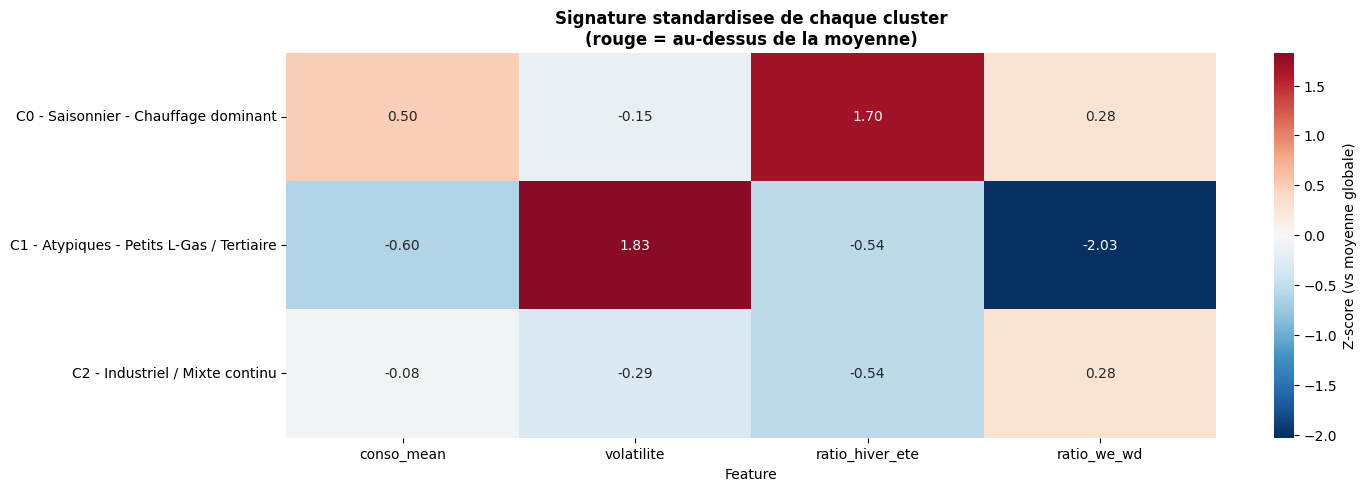

In [40]:
# 6. VISUALISATIONS : HEATMAP CENTROIDES + DISPERSION DE TAILLE
fig, axes = plt.subplots(1, 1, figsize=(15, 5))

centroids_scaled_df = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=features_clustering,
    index=[f"C{c} - {cluster_labels[c]}" for c in range(3)],
)
sns.heatmap(
    centroids_scaled_df,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    ax=axes,
    cbar_kws={'label': 'Z-score (vs moyenne globale)'},
)
axes.set_title("Signature standardisee de chaque cluster\n(rouge = au-dessus de la moyenne)", fontweight='bold')
axes.set_xlabel("Feature")
axes.set_ylabel("");

In [41]:
# 7. DETECTION D'ANOMALIES : DISTANCE AU CENTROIDE + DRIFT Z-SCORE
# ces points doivent être étudiés à la main avant de prendre une décision
distances = np.zeros(len(profils_final))
for c in range(3):
    mask = profils_final['cluster'].values == c
    distances[mask] = np.linalg.norm(X_scaled[mask] - kmeans_final.cluster_centers_[c], axis=1)
profils_final['dist_to_centroid'] = distances

profils_final['drift_zscore'] = profils_final.groupby('cluster')['dist_to_centroid'].transform(
    lambda s: (s - s.mean()) / s.std()
)

print("CANDIDATS A LA REVUE DE PORTEFEUILLE (drift z-score > 1.5)")

suspects = profils_final[profils_final['drift_zscore'] > 1.5].sort_values('drift_zscore', ascending=False)
if len(suspects) > 0:
    print(
        suspects[
            ['pointKey', 'cluster_label', 'conso_mean', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd', 'drift_zscore']
        ].round(3).to_string()
    )
else:
    print("Aucun point au-dela de 1.5 sigma -- portefeuille stable.")

CANDIDATS A LA REVUE DE PORTEFEUILLE (drift z-score > 1.5)
     pointKey                    cluster_label  conso_mean  volatilite  ratio_hiver_ete  ratio_we_wd  drift_zscore
4   FNC-00005       Industriel / Mixte continu     358.301       0.190            1.099        0.824         2.734
34  FNC-00210       Industriel / Mixte continu     154.052       0.593            1.097        0.631         1.920
7   FNC-00013  Saisonnier - Chauffage dominant     588.230       0.225            2.694        0.877         1.732


In [42]:
# 8. EXPORT DU TABLEAU FINAL DE SEGMENTATION (utilisable par un desk)
export_cols = [
    'pointKey', 'pointLabel', 'operatorLabel', 'country',
    'cluster', 'cluster_label',
    'conso_mean', 'volatilite', 'ratio_hiver_ete', 'ratio_we_wd',
    'dist_to_centroid', 'drift_zscore',
]
profils_final[export_cols].sort_values(['cluster', 'dist_to_centroid']).to_csv(
    '../data/clean/segmentation_finale.csv', index=False
)

# Pipeline Clustering avec fonctions packagés

Dans le cadre du rendu, nous avons essayé de packager nos recherche.  
L'idée est de pouvoir rendre cette analyse répétable plus rapidement et avec des nouvelles données, sur une autre période etc...  
La cellule qui suit contient le pipeline entier grâce aux fonctions packagés.   
Les résultats (legérement différents des précédents) ne sont pas analysés.

In [43]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from gas_intelligence.config import (
    CLUSTERING_FEATURES, CLUSTER_NAMES, INFINITE_RATIO_FILL,
    K_OPTIMAL, KMEANS_N_INIT, RANDOM_STATE,
)
from gas_intelligence.data_processing.cleaning import (
    encode_infinite_ratios, identify_outliers, remove_outliers,
)
from gas_intelligence.data_processing.feature_engineering import engineer_all_features

# 1. Donnee brute -> filtrage minimal
df = pd.read_csv("../data/raw/consumption_2020-01-01_to_2025-12-01_day.csv", low_memory=False)
df = df[(df["directionKey"] == "exit") & (df["flowStatus"] == "Confirmed")
        & (df["idPointType"] == 18) & df["value"].notna()].copy()
df["date"] = pd.to_datetime(df["periodFrom"])
df["value_gwh"] = df["value"].astype(float) / 1_000_000.0

# 2. Features + nettoyage via le package
profils = engineer_all_features(df, date_column="date", value_column="value_gwh")
profils = remove_outliers(profils, identify_outliers(profils))
profils = encode_infinite_ratios(profils, fill_value=INFINITE_RATIO_FILL)
profils = profils.dropna(subset=CLUSTERING_FEATURES).reset_index(drop=True)

# 3. Clustering
X = StandardScaler().fit_transform(profils[CLUSTERING_FEATURES])
profils["cluster"] = KMeans(
    n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=KMEANS_N_INIT
).fit_predict(X)
profils["cluster_label"] = profils["cluster"].map(CLUSTER_NAMES)

profils["cluster_label"].value_counts()


cluster_label
Saisonnier - Chauffage dominant         27
Industriel / Mixte continu               4
Atypiques - Petits L-Gas / Tertiaire     2
Name: count, dtype: int64